In [1]:
from pyhipp import plot
from sidm.yangyao import profiles, models
import numpy as np

## The cosmology and unit system

In [2]:
cosm = profiles.default_cosm
cosm.params

[ {'name': 'hubble', 'value': 0.6774}, {'name': 'omega_m0', 'value': 0.3089},
  {'name': 'omega_l0', 'value': 0.6911}, {'name': 'omega_b0', 'value': 0.0486},
  {'name': 'sigma_8', 'value': 0.8159}, {'name': 'n_spec', 'value': 0.9667},
  {'name': 't_cmb', 'value': 2.7255}]

In [3]:
us = cosm.unit_system
us

{ 'u_l': '4.555178006335056e+22 m',
  'u_t': '4.658635961027458e+16 s',
  'u_m': '2.935355581189919e+40 kg',
  'u_v': '977792.2216807893 m / s'}

In [4]:
M_v = 1.0e12 / us.u_m_to_sol                            # a halo with mass 10^12 Msun, converted to internal units
R_v = cosm.halo_theory.vir_props_crit(M_v, z=0.).r_phy  # physical virial radius
print(f'{M_v=}, {R_v=}')

M_v=np.float64(67.74000000000001), R_v=np.float64(0.14282429654564824)


In [5]:
R_v * us.u_l_to_pc, M_v * us.u_m_to_sol                 # convert back to pc and Msun

(np.float64(210841.8903833012), np.float64(1000000000000.0))

## Profiles

By default, the cosmology and the corresponding unit system in used are the 
default ones shown above.

Here we plot the density and rotation curve of an NFW halo.

In [6]:
halo = profiles.NFW(M_v, R_v, c=10)

[ <pyhipp.plot.axes.Axes object at 0x33e7b5d10>,

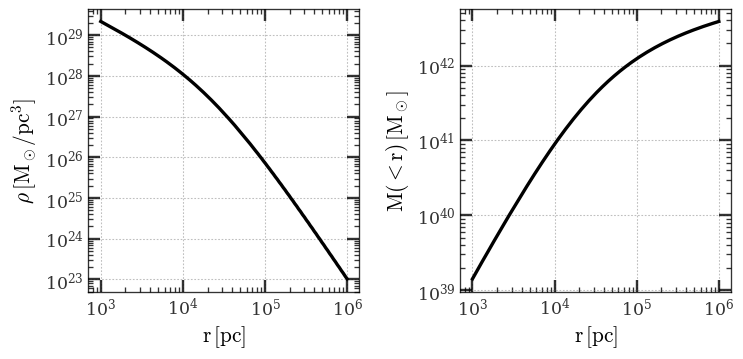

In [11]:
rs = np.logspace(-3., 0., 128) * 1e6 / us.u_l_to_pc     # 0.001 Mpc to 1 Mpc    
lg_rs = np.log10(rs)

pf = halo.profile._impl
rhos = pf.rhos(lg_rs) * us.u_m / us.u_l_to_pc**3        # density
Ms = pf.M_encs(lg_rs) * us.u_m                          # enclosed mass
rs = rs * us.u_l_to_pc                                  # convert back to pc

fig, axs = plot.subplots((1,2), share=False)
axs_f = axs.flat

ax = axs_f[0]
ax.plot(rs, rhos).label(r'r\,[{\rm pc}]', r'\rho\,[{\rm M_\odot/pc^3}]')

ax = axs_f[1]
ax.plot(rs, Ms).label(r'r\,[{\rm pc}]', r'M(<r)\,[{\rm M_\odot}]')

axs.scale('log', 'log')